In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Colab Notebooks/ML"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install cairosvg lxml --quiet
!pip install mup --quiet

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import random, math, time, os, json
import numpy as np
import matplotlib.pyplot as plt
from lxml import etree
from mup import MuReadout, set_base_shapes, MuAdamW
from tokenizers import Tokenizer

In [ ]:
import re
from lxml import etree

In [ ]:
try:
    import cairosvg
    CAIROSVG_AVAILABLE = True
except ImportError:
    CAIROSVG_AVAILABLE = False
    print("cairosvg not available — render-rate metric will be skipped")

In [ ]:
tokenizer    = Tokenizer.from_file(base_path + "/svg_tokenizer.json")
train_tokens = torch.load(base_path + "/train_tokens.pt")
val_tokens   = torch.load(base_path + "/val_tokens.pt")
test_tokens  = torch.load(base_path + "/test_tokens.pt")

VOCAB_SIZE = tokenizer.get_vocab_size()
print(f"Vocab size  : {VOCAB_SIZE}")
print(f"Train tokens: {sum(len(x) for x in train_tokens):,}")

Vocab size  : 4000
Train tokens: 130,335,440


In [ ]:
class ModelConfig:
    def __init__(self, d_model, n_layer, n_head,
                 block_size=256, vocab_size=4000,
                 dropout=0.1, ff_mult=4):
        self.n_embd    = d_model
        self.n_layer   = n_layer
        self.n_head    = n_head
        self.block_size = block_size
        self.vocab_size = vocab_size
        self.dropout   = dropout
        self.ff_mult   = ff_mult

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn  = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj  = nn.Linear(config.n_embd, config.n_embd)
        self.n_head  = config.n_head
        self.dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C   = x.size()
        q, k, v   = self.c_attn(x).split(C, dim=2)
        head_size = C // self.n_head
        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)
        # µP attention scaling: 1/d instead of 1/sqrt(d)
        att = (q @ k.transpose(-2, -1)) / head_size
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)
        y   = att @ v
        y   = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.mlp  = nn.Sequential(
            nn.Linear(config.n_embd, config.ff_mult * config.n_embd),
            nn.GELU(),
            nn.Linear(config.ff_mult * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config  = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks  = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f    = nn.LayerNorm(config.n_embd)
        self.head    = MuReadout(config.n_embd, config.vocab_size)  # µP output layer

    def forward(self, idx, targets=None):
        B, T   = idx.shape
        pos    = torch.arange(0, T, device=idx.device)
        x      = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x      = self.blocks(x)
        x      = self.ln_f(x)
        logits = self.head(x)
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond  = idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                cumprobs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                remove   = cumprobs - F.softmax(sorted_logits, dim=-1) > top_p
                sorted_logits[remove] = float('-inf')
                logits = torch.zeros_like(logits).scatter_(1, sorted_idx, sorted_logits)

            probs  = F.softmax(logits, dim=-1)
            next_t = torch.multinomial(probs, num_samples=1)
            idx    = torch.cat([idx, next_t], dim=1)
        return idx

In [ ]:
BASE_CONFIG  = ModelConfig(128, 6, 4)
DELTA_CONFIG = ModelConfig(192, 6, 6)
base_model   = GPT(BASE_CONFIG)
delta_model  = GPT(DELTA_CONFIG)


BEST_CONFIG = ModelConfig(768, 6, 12) # XL

In [ ]:
def get_batch(tokens, batch_size, block_size, device):
    x = torch.zeros((batch_size, block_size), dtype=torch.long)
    y = torch.zeros((batch_size, block_size), dtype=torch.long)
    for i in range(batch_size):
        doc = random.choice(tokens)
        while len(doc) <= block_size + 1:
            doc = random.choice(tokens)
        start = random.randint(0, len(doc) - block_size - 1)
        chunk = doc[start:start + block_size + 1]
        x[i]  = torch.tensor(chunk[:-1])
        y[i]  = torch.tensor(chunk[1:])
    return x.to(device), y.to(device)


@torch.no_grad()
def evaluate(model, val_tokens, config, device, steps=100):
    model.eval()
    losses = []
    for _ in range(steps):
        x, y = get_batch(val_tokens, 16, config.block_size, device)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def get_lr(step, max_steps, base_lr, warmup_steps):
    if step < warmup_steps:
        return base_lr * step / warmup_steps
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    return base_lr * 0.5 * (1 + math.cos(math.pi * progress))

In [ ]:
BEST_MUP_LR = 0.003 # smaller learning rate
NUM_EPOCHS  = 3
BATCH_SIZE  = 32
BLOCK_SIZE  = BEST_CONFIG.block_size
SAVE_PATH   = base_path + "/part4_best_model.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = GPT(BEST_CONFIG)
set_base_shapes(model, base_model, delta=delta_model)  # µP applied here
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

optimizer = MuAdamW(model.parameters(), lr=BEST_MUP_LR, weight_decay=0.1)

tokens_per_step  = BATCH_SIZE * BLOCK_SIZE
total_train_toks = sum(len(x) for x in train_tokens)
steps_per_epoch  = total_train_toks // tokens_per_step
total_steps      = steps_per_epoch * NUM_EPOCHS
warmup_steps     = int(0.07 * total_steps) # slightly longer warmup

print(f"Steps per epoch : {steps_per_epoch:,}")
print(f"Total steps     : {total_steps:,}  ({NUM_EPOCHS} epochs)")

all_train_losses = []        # one float per step
all_val_losses   = []        # list of (step, val_loss)
best_val         = float("inf")

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

start_time = time.time()

for step in range(total_steps):
    cur_lr = get_lr(step, total_steps, BEST_MUP_LR, warmup_steps)
    for pg in optimizer.param_groups:
        pg['lr'] = cur_lr

    x, y = get_batch(train_tokens, BATCH_SIZE, BLOCK_SIZE, device)
    _, loss = model(x, y)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    all_train_losses.append(loss.item())

    if step % 1000 == 0:
        val_loss = evaluate(model, val_tokens, BEST_CONFIG, device)
        all_val_losses.append((step, val_loss))
        epoch   = step // steps_per_epoch + 1
        elapsed = time.time() - start_time
        print(f"epoch {epoch} | step {step}/{total_steps} | "
              f"val {val_loss:.4f} | lr {cur_lr:.2e} | {elapsed:.0f}s")

        if val_loss < best_val:
            best_val = val_loss
            torch.save({
                "model_state": model.state_dict(),
                "step":        step,
                "val_loss":    val_loss,
            }, SAVE_PATH)

total_time = time.time() - start_time
throughput = (total_steps * tokens_per_step) / total_time
max_mem    = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else 0

print(f"\nTraining done: {total_time:.0f}s | {throughput:.0f} tok/s | {max_mem:.2f} GB peak")

Device: cuda
Parameters: 48,873,376
Steps per epoch : 15,910
Total steps     : 47,730  (3 epochs)
epoch 1 | step 0/47730 | val 8.3447 | lr 0.00e+00 | 3s
epoch 1 | step 1000/47730 | val 0.9487 | lr 8.98e-04 | 173s
epoch 1 | step 2000/47730 | val 0.7854 | lr 1.80e-03 | 343s
epoch 1 | step 3000/47730 | val 0.8957 | lr 2.69e-03 | 514s
epoch 1 | step 4000/47730 | val 0.7343 | lr 3.00e-03 | 683s
epoch 1 | step 5000/47730 | val 0.7166 | lr 2.99e-03 | 854s
epoch 1 | step 6000/47730 | val 0.8312 | lr 2.97e-03 | 1024s
epoch 1 | step 7000/47730 | val 0.7058 | lr 2.95e-03 | 1194s
epoch 1 | step 8000/47730 | val 0.6772 | lr 2.92e-03 | 1364s
epoch 1 | step 9000/47730 | val 0.6486 | lr 2.88e-03 | 1534s
epoch 1 | step 10000/47730 | val 0.6509 | lr 2.84e-03 | 1704s
epoch 1 | step 11000/47730 | val 1.0972 | lr 2.78e-03 | 1874s
epoch 1 | step 12000/47730 | val 0.7108 | lr 2.73e-03 | 2044s
epoch 1 | step 13000/47730 | val 0.6606 | lr 2.66e-03 | 2214s
epoch 1 | step 14000/47730 | val 0.6548 | lr 2.59e-03 |

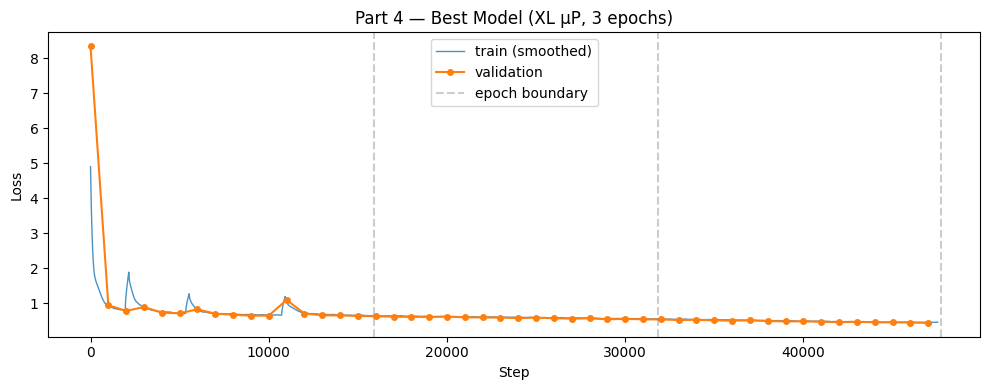

In [ ]:
window = 200
smooth = np.convolve(all_train_losses, np.ones(window)/window, mode='valid')
val_x  = [v[0] for v in all_val_losses]
val_y  = [v[1] for v in all_val_losses]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(smooth, alpha=0.8, label="train (smoothed)", linewidth=1)
ax.plot(val_x, val_y, "o-", label="validation", linewidth=1.5, markersize=4)
for i in range(1, NUM_EPOCHS + 1):
    ax.axvline(i * steps_per_epoch, color='gray', linestyle='--', alpha=0.4,
               label="epoch boundary" if i == 1 else None)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"Part 4 — Best Model (XL µP, {NUM_EPOCHS} epochs)")
ax.legend()
plt.tight_layout()
plt.savefig(base_path + "/part4_training_curve.png", dpi=150)
plt.show()

In [ ]:
checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"\nLoaded best checkpoint: step {checkpoint['step']}, "
      f"val={checkpoint['val_loss']:.4f}")


Loaded best checkpoint: step 47000, val=0.4434


In [ ]:
print("Computing test perplexity...")

@torch.no_grad()
def compute_perplexity(model, tokens, config, device, steps=200):
    model.eval()
    total_loss, n = 0.0, 0
    for _ in range(steps):
        x, y = get_batch(tokens, 16, config.block_size, device)
        _, loss = model(x, y)
        total_loss += loss.item()
        n += 1
    avg_loss = total_loss / n
    return avg_loss, math.exp(avg_loss)

test_loss, test_ppl = compute_perplexity(model, test_tokens, BEST_CONFIG, device)
print(f"Test loss : {test_loss:.4f}")
print(f"Test PPL  : {test_ppl:.2f}")

Computing test perplexity...
Test loss : 0.4510
Test PPL  : 1.57


In [ ]:
def encode_prefix(text):
    enc = tokenizer.encode(text)
    return torch.tensor([enc.ids], dtype=torch.long)

def decode_tokens(ids):
    return tokenizer.decode(ids)

def clean_svg(raw):
    text = raw
    text = text.replace('"', "'")
    text = text.replace("Ġ", " ")
    text = re.sub(r'(\d+)\s*\.\s*(\d+)', r'\1.\2', text)
    text = re.sub(r"'\s*\.\s*(\d)", r"'.\1", text)
    text = re.sub(r" \.\s*(\d)", r" .\1", text)
    text = re.sub(r'(\d)\s+(px|em|rem|pt|%)', r'\1\2', text)
    text = re.sub(r'(\w+)\s*-\s*(\w+)(\s*=)', r'\1-\2\3', text)
    text = re.sub(r'<\s*/\s*(\w[\w.-]*)\s*>', r'</\1>', text)
    text = re.sub(r'<\s+(\w)', r'<\1', text)
    text = re.sub(r'/\s+>', '/>', text)
    text = re.sub(r"\s*=\s*'", "='", text)
    text = re.sub(r"='\s+", "='", text)
    text = re.sub(r" +'(>)", r"'\1", text)
    text = re.sub(r" +'(/>)", r"'\1", text)
    text = re.sub(r" +'( \w)", r"'\1", text)
    text = re.sub(r"xmlns='[^']*'", "xmlns='http://www.w3.org/2000/svg'", text)
    text = re.sub(r'  +', ' ', text)
    text = text.strip()

    # Cut at the first </svg> — discard everything after
    first_close = text.find('</svg>')
    if first_close != -1:
        text = text[:first_close + len('</svg>')]
    else:
        # No </svg> — cut at last complete closing tag and add </svg>
        last_close = text.rfind('</')
        if last_close != -1:
            end = text.find('>', last_close)
            if end != -1:
                text = text[:end + 1] + '</svg>'
        else:
            text = text + '</svg>'

    return text.strip()
svg_start_ids = tokenizer.encode("<svg").ids
print(f"SVG start token ids: {svg_start_ids}")

SVG start token ids: [97, 112]


In [ ]:
print("\n=== Unconditional generation ===")

UNCONDITIONAL_N = 10
TEMPS           = [0.5, 0.8, 1.0]
MAX_NEW_TOKENS  = 1024

unconditional_samples = {}
for temp in TEMPS:
    samples = []
    for i in range(UNCONDITIONAL_N):
        seed     = torch.tensor([svg_start_ids], dtype=torch.long).to(device)
        out      = model.generate(seed, MAX_NEW_TOKENS,
                                  temperature=temp, top_k=50, top_p=0.95)
        raw_text = decode_tokens(out[0].tolist())
        svg_text = clean_svg(raw_text)
        samples.append(svg_text)
        print(f"  T={temp} sample {i+1}: {len(svg_text)} chars")
    unconditional_samples[temp] = samples



=== Unconditional generation ===
  T=0.5 sample 1: 1043 chars
  T=0.5 sample 2: 1021 chars
  T=0.5 sample 3: 1043 chars
  T=0.5 sample 4: 742 chars
  T=0.5 sample 5: 533 chars
  T=0.5 sample 6: 1511 chars
  T=0.5 sample 7: 597 chars
  T=0.5 sample 8: 1366 chars
  T=0.5 sample 9: 1272 chars
  T=0.5 sample 10: 1098 chars
  T=0.8 sample 1: 1457 chars
  T=0.8 sample 2: 533 chars
  T=0.8 sample 3: 596 chars
  T=0.8 sample 4: 1299 chars
  T=0.8 sample 5: 647 chars
  T=0.8 sample 6: 686 chars
  T=0.8 sample 7: 550 chars
  T=0.8 sample 8: 1235 chars
  T=0.8 sample 9: 1169 chars
  T=0.8 sample 10: 909 chars
  T=1.0 sample 1: 784 chars
  T=1.0 sample 2: 667 chars
  T=1.0 sample 3: 1319 chars
  T=1.0 sample 4: 613 chars
  T=1.0 sample 5: 853 chars
  T=1.0 sample 6: 674 chars
  T=1.0 sample 7: 1104 chars
  T=1.0 sample 8: 1072 chars
  T=1.0 sample 9: 1155 chars
  T=1.0 sample 10: 590 chars


In [ ]:
print("\n=== Prefix-conditioned generation ===")

PREFIXES = [
    ('<svg viewBox="0 0 100 100" xmlns="http://www.w3.org/2000/svg">'
     '<circle cx="50" cy="50" r="40" fill="none" stroke="black" stroke-width="2"/>'
     '<circle cx="35" cy="45" r="5" fill="black"/>',
     "partial face (circle + one eye)"),

    ('<svg viewBox="0 0 100 100" xmlns="http://www.w3.org/2000/svg">'
     '<path d="M10 50 C30 10, 70 10,',
     "open path"),

    ('<svg viewBox="0 0 100 100" xmlns="http://www.w3.org/2000/svg">'
     '<g><circle cx="50" cy="50" r="20" fill="blue"/>',
     "group with one shape"),

    ('<svg viewBox="0 0 100 100" xmlns="http://www.w3.org/2000/svg">'
     '<polygon points="50,10 61,35 98,35 68,57 79,91 50,70 21,91 32,57 2,35 39,35"'
     ' fill="gold" stroke="black" stroke-width="2"/>',
     "complete star polygon"),

    ('<svg viewBox="0 0 100 100" xmlns="http://www.w3.org/2000/svg">'
     '<rect x="10" y="10" width="80" height="80" rx="8" fill="#f0f0f0"/>',
     "card rect"),
]

prefix_samples = []
for prefix_text, label in PREFIXES:
    seed     = encode_prefix(prefix_text).to(device)
    out      = model.generate(seed, MAX_NEW_TOKENS,
                              temperature=0.8, top_k=50, top_p=0.95)
    # Decode the full output
    raw_full = decode_tokens(out[0].tolist())

    # The prefix tokens decode to some number of chars — find where
    # the model's continuation starts by decoding just the prefix tokens
    prefix_token_ids = tokenizer.encode(prefix_text).ids
    raw_prefix_decoded = decode_tokens(prefix_token_ids)

    # Split: keep original prefix_text, clean only the continuation
    # Find the continuation in the raw output by skipping the prefix portion
    continuation_raw = raw_full[len(raw_prefix_decoded):]

    # Reconstruct: original prefix + cleaned continuation
    svg_text = clean_svg(prefix_text + continuation_raw)

    prefix_samples.append({
        "label":      label,
        "prefix":     prefix_text,
        "completion": svg_text,
    })
    print(f"  [{label}] → {len(svg_text)} chars")


=== Prefix-conditioned generation ===
  [partial face (circle + one eye)] → 678 chars
  [open path] → 2150 chars
  [group with one shape] → 675 chars
  [complete star polygon] → 814 chars
  [card rect] → 2107 chars


In [ ]:
print("\n=== XML debug (T=0.5) ===")
for i, s in enumerate(unconditional_samples[0.5]):
    try:
        etree.fromstring(s.encode())
        print(f"  Sample {i}: VALID")
    except etree.XMLSyntaxError as e:
        print(f"  Sample {i}: {e}")
        # show exactly where it breaks
        col = e.position[1] if e.position else 0
        print(f"    ...{repr(s[max(0,col-40):col+40])}...")


=== XML debug (T=0.5) ===
  Sample 0: VALID
  Sample 1: VALID
  Sample 2: VALID
  Sample 3: VALID
  Sample 4: VALID
  Sample 5: VALID
  Sample 6: VALID
  Sample 7: VALID
  Sample 8: VALID
  Sample 9: VALID


In [ ]:
print("\n=== Evaluation metrics ===")

def is_valid_xml(svg_text):
    try:
        etree.fromstring(svg_text.encode())
        return True
    except Exception:
        return False

def has_svg_root(svg_text):
    txt = svg_text.strip()
    return txt.startswith("<svg") and "</svg>" in txt

def can_render(svg_text):
    if not CAIROSVG_AVAILABLE:
        return None
    try:
        cairosvg.svg2png(bytestring=svg_text.encode(), write_to="/dev/null")
        return True
    except Exception:
        return False

def evaluate_samples(samples, label=""):
    xml_ok    = [is_valid_xml(s) for s in samples]
    svg_ok    = [has_svg_root(s) for s in samples]
    render_ok = [can_render(s)   for s in samples]
    n         = len(samples)
    print(f"\n{label} (n={n})")
    print(f"  XML valid   : {sum(xml_ok)/n*100:.1f}%  ({sum(xml_ok)}/{n})")
    print(f"  SVG root    : {sum(svg_ok)/n*100:.1f}%  ({sum(svg_ok)}/{n})")
    renderable = [r for r in render_ok if r is not None]
    if renderable:
        print(f"  Render rate : {sum(renderable)/len(renderable)*100:.1f}%"
              f"  ({sum(renderable)}/{len(renderable)})")
    else:
        print("  Render rate : N/A (cairosvg not available)")
    return {"xml_rate": sum(xml_ok)/n, "svg_rate": sum(svg_ok)/n,
            "render_ok": render_ok}

all_uncond     = [s for t in TEMPS for s in unconditional_samples[t]]
metrics_uncond = evaluate_samples(all_uncond,               "Unconditional (all temps)")
metrics_t05    = evaluate_samples(unconditional_samples[0.5], "Temperature 0.5")
metrics_t08    = evaluate_samples(unconditional_samples[0.8], "Temperature 0.8")
metrics_t10    = evaluate_samples(unconditional_samples[1.0], "Temperature 1.0")
metrics_prefix = evaluate_samples(
    [p["completion"] for p in prefix_samples], "Prefix-conditioned")


=== Evaluation metrics ===

Unconditional (all temps) (n=30)
  XML valid   : 100.0%  (30/30)
  SVG root    : 100.0%  (30/30)
  Render rate : 100.0%  (30/30)

Temperature 0.5 (n=10)
  XML valid   : 100.0%  (10/10)
  SVG root    : 100.0%  (10/10)
  Render rate : 100.0%  (10/10)

Temperature 0.8 (n=10)
  XML valid   : 100.0%  (10/10)
  SVG root    : 100.0%  (10/10)
  Render rate : 100.0%  (10/10)

Temperature 1.0 (n=10)
  XML valid   : 100.0%  (10/10)
  SVG root    : 100.0%  (10/10)
  Render rate : 100.0%  (10/10)

Prefix-conditioned (n=5)
  XML valid   : 40.0%  (2/5)
  SVG root    : 100.0%  (5/5)
  Render rate : 40.0%  (2/5)


In [ ]:
save_dir = base_path + "/part4_samples"
os.makedirs(save_dir, exist_ok=True)

for temp in TEMPS:
    for i, svg in enumerate(unconditional_samples[temp]):
        fname = f"{save_dir}/uncond_T{str(temp).replace('.','')}_s{i+1:02d}.svg"
        with open(fname, "w") as f:
            f.write(svg)

for i, item in enumerate(prefix_samples):
    fname = f"{save_dir}/prefix_{i+1:02d}_{item['label'][:20].replace(' ','_')}.svg"
    with open(fname, "w") as f:
        f.write(item["completion"])

print(f"\nSamples saved to {save_dir}/")


Samples saved to /content/drive/MyDrive/Colab Notebooks/ML/part4_samples/


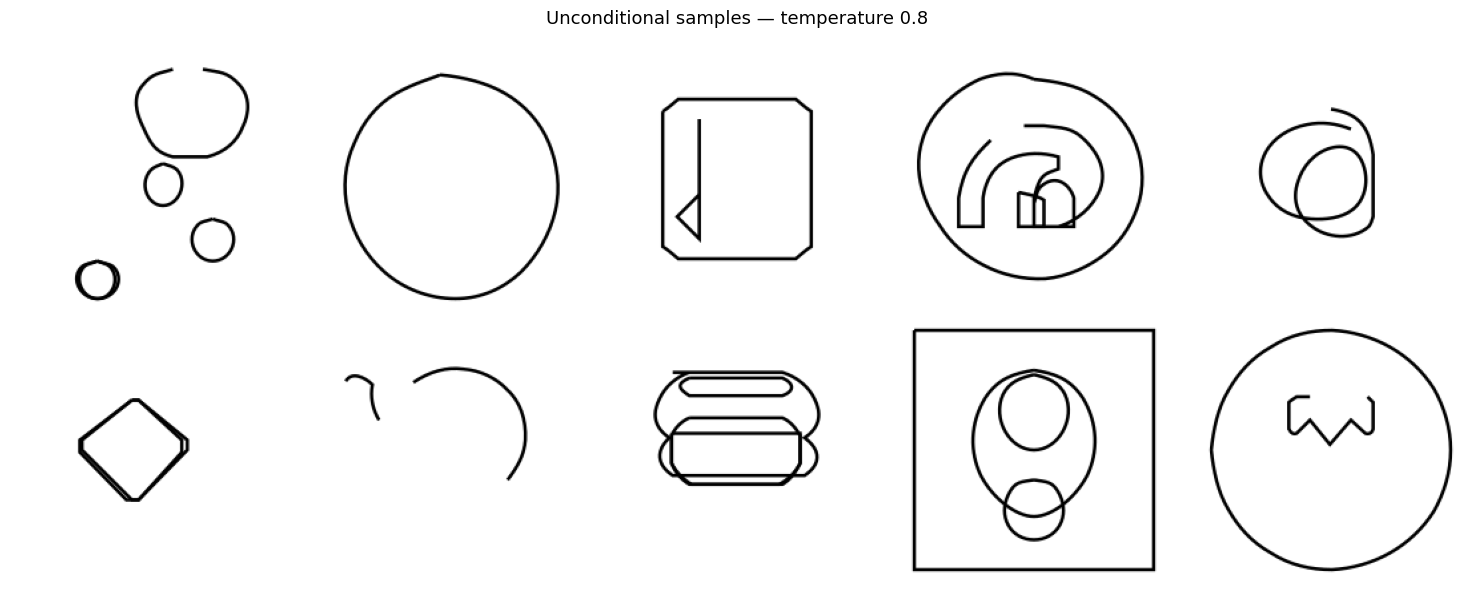

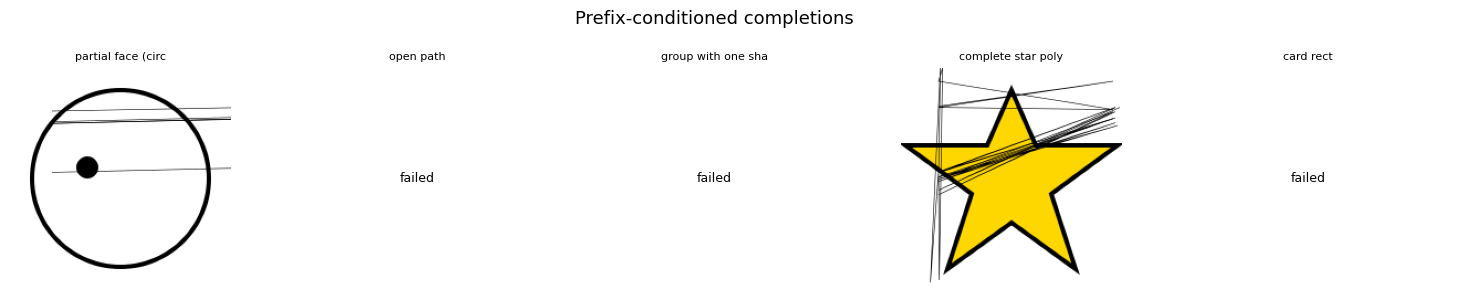

In [ ]:
if CAIROSVG_AVAILABLE:
    from PIL import Image
    import io

    def svg_to_pil(svg_text, size=200):
        try:
            png = cairosvg.svg2png(bytestring=svg_text.encode(),
                                   output_width=size, output_height=size)
            return Image.open(io.BytesIO(png))
        except Exception:
            return None

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for ax, svg_text in zip(axes.flatten(), unconditional_samples[0.8]):
        img = svg_to_pil(svg_text)
        ax.imshow(img) if img else ax.text(0.5, 0.5, "failed",
            ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.axis("off")
    fig.suptitle("Unconditional samples — temperature 0.8", fontsize=13)
    plt.tight_layout()
    plt.savefig(base_path + "/part4_sample_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

    fig2, axes2 = plt.subplots(1, 5, figsize=(15, 3))
    for ax, item in zip(axes2, prefix_samples):
        img = svg_to_pil(item["completion"])
        ax.imshow(img) if img else ax.text(0.5, 0.5, "failed",
            ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_title(item["label"][:18], fontsize=8)
        ax.axis("off")
    fig2.suptitle("Prefix-conditioned completions", fontsize=13)
    plt.tight_layout()
    plt.savefig(base_path + "/part4_prefix_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("\n=== SVG text previews (T=0.8, first 5) ===")
    for i, svg in enumerate(unconditional_samples[0.8][:5]):
        print(f"\n--- Sample {i+1} ---\n{svg[:300]}...")

In [ ]:
print("\n" + "="*60)
print("PART 4 SUMMARY")
print("="*60)
print(f"Model          : XL µP (768d, 6L, 12H) — {total_params:,} params")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Training time  : {total_time:.0f}s")
print(f"Throughput     : {throughput:.0f} tok/s")
print(f"Peak GPU mem   : {max_mem:.2f} GB")
print(f"Test loss      : {test_loss:.4f}")
print(f"Test PPL       : {test_ppl:.2f}")
print(f"XML valid (all): {metrics_uncond['xml_rate']*100:.1f}%")
print(f"SVG root (all) : {metrics_uncond['svg_rate']*100:.1f}%")
print("="*60)

summary = {
    "model":            "XL µP (768d, 6L, 12H)",
    "model_params":     total_params,
    "epochs":           NUM_EPOCHS,
    "best_mup_lr":      BEST_MUP_LR,
    "training_time_s":  total_time,
    "throughput_toks":  throughput,
    "peak_gpu_gb":      max_mem,
    "test_loss":        test_loss,
    "test_perplexity":  test_ppl,
    "xml_validity_pct": metrics_uncond["xml_rate"] * 100,
    "svg_root_pct":     metrics_uncond["svg_rate"] * 100,
    "best_checkpoint":  SAVE_PATH,
    "samples_dir":      save_dir,
}
with open(base_path + "/part4_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to {base_path}/part4_summary.json")
print("Done!")


PART 4 SUMMARY
Model          : XL µP (768d, 6L, 12H) — 48,873,376 params
Epochs         : 3
Training time  : 8118s
Throughput     : 48163 tok/s
Peak GPU mem   : 5.55 GB
Test loss      : 0.4510
Test PPL       : 1.57
XML valid (all): 100.0%
SVG root (all) : 100.0%
Summary saved to /content/drive/MyDrive/Colab Notebooks/ML/part4_summary.json
Done!


In [1]:
!pip install cairosvg lxml --quiet
!pip install mup --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Mounted at /content/drive


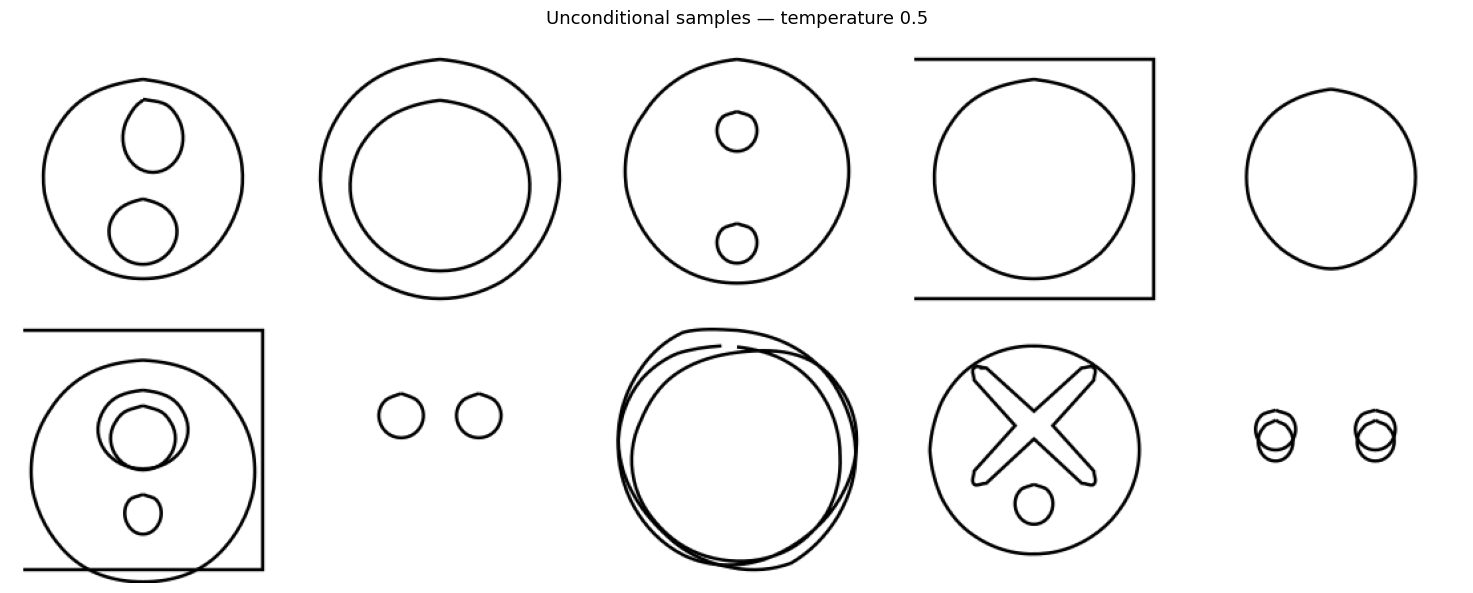

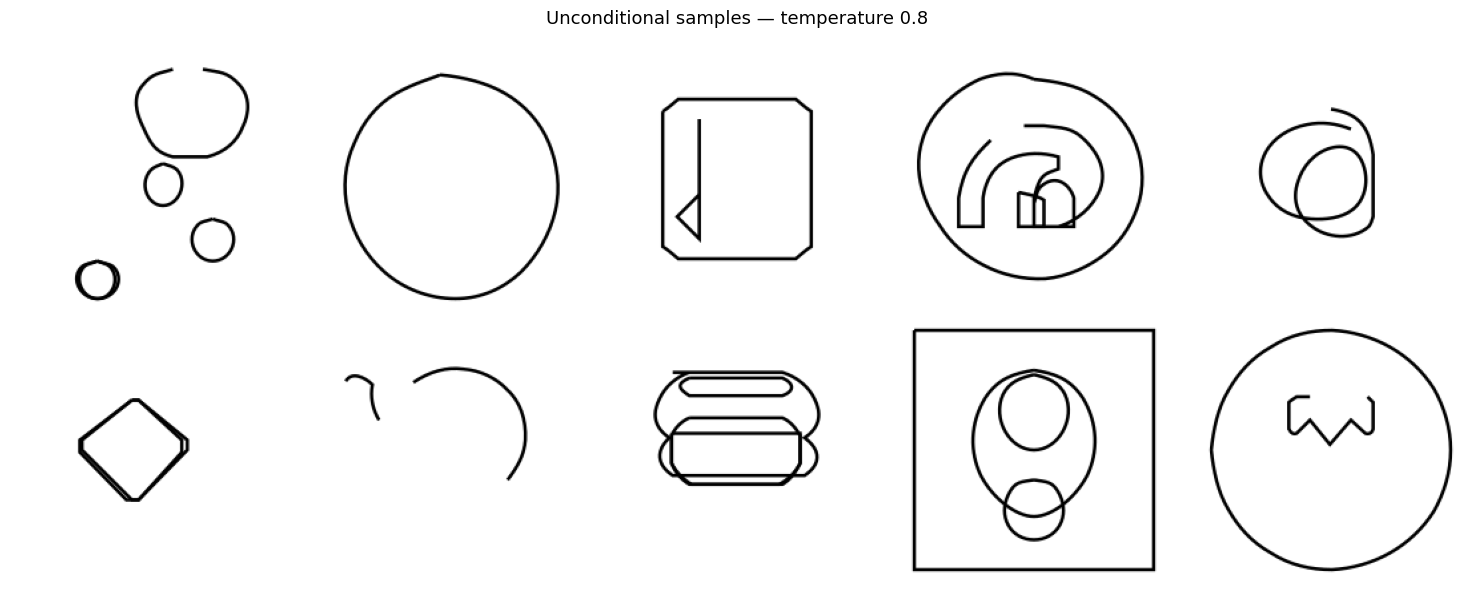

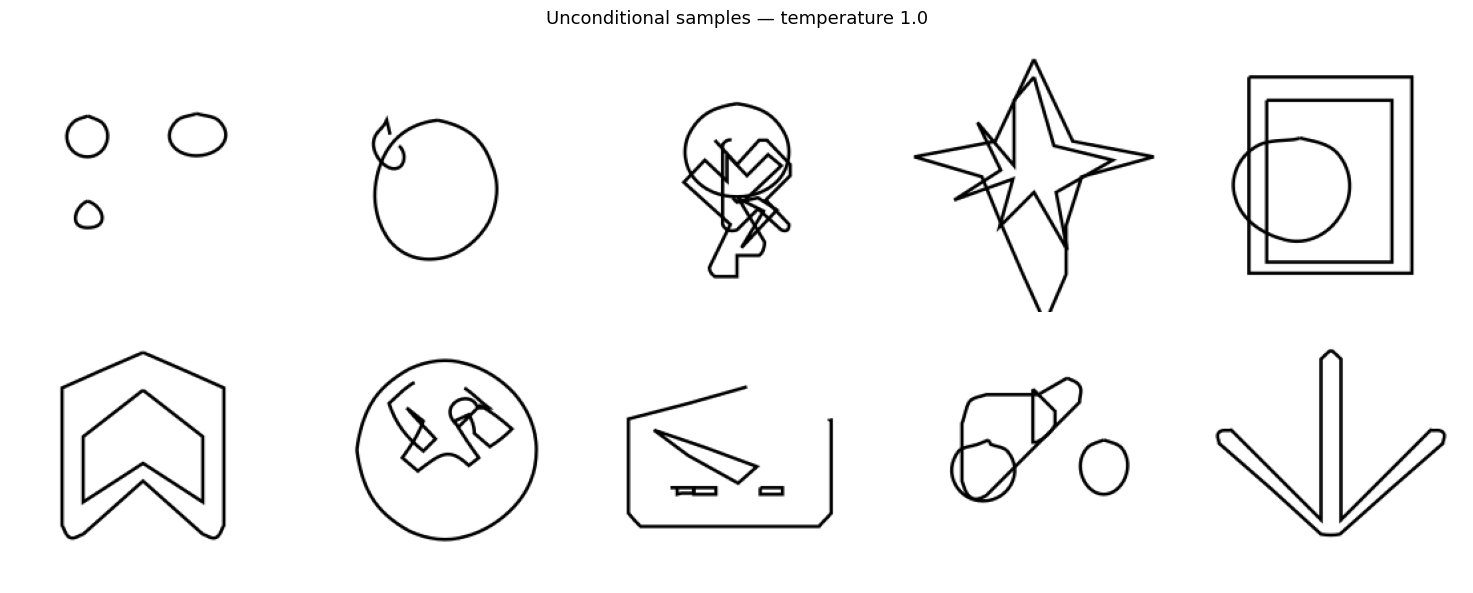

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install cairosvg --quiet

import os, cairosvg
from PIL import Image
import io, matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Colab Notebooks/ML"
save_dir  = base_path + "/part4_samples"

TEMPS = [0.5, 0.8, 1.0]

for temp in TEMPS:
    pattern = f"uncond_T{str(temp).replace('.','')}_"
    files   = sorted([f for f in os.listdir(save_dir) if f.startswith(pattern)])

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for ax, fname in zip(axes.flatten(), files):
        fpath = os.path.join(save_dir, fname)
        with open(fpath, "r") as f:
            svg_text = f.read()
        try:
            png = cairosvg.svg2png(bytestring=svg_text.encode(),
                                   output_width=200, output_height=200)
            img = Image.open(io.BytesIO(png))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "failed", ha='center', va='center',
                    transform=ax.transAxes, fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Unconditional samples — temperature {temp}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [4]:
import os

save_dir = base_path + "/part4_samples"

for fname in sorted(os.listdir(save_dir)):
    if fname.endswith(".svg"):
        with open(os.path.join(save_dir, fname), "r") as f:
            print(f"\n--- {fname} ---")
            print(f.read())


--- prefix_01_partial_face_(circle.svg ---
<svg viewBox='0 0 100 100' xmlns='http://www.w3.org/2000/svg'><circle cx='50' cy='50' r='40' fill='none' stroke='black' stroke-width='2'/><circle cx='35' cy='45' r='5' fill='black'/> <path fill='none ' stroke='black ' stroke-width='.3 ' stroke-opacity='1.0 ' filling='0 ' d='M 19 47.2 2088.6 L 19 47.2 1103.0'></path> <path fill='none ' stroke='black ' stroke-width='.3 ' stroke-opacity='1.0 ' filling='0 ' d='M 19 25.1 1114.3 L 19 25.1 1121.0 L 19 25.1 1048.8 L 19 24.3 1050.5 L 19 25.1 1047.5'></path> <path fill='none ' stroke='black ' stroke-width='.3 ' stroke-opacity='1.0 ' filling='0 ' d='M 19 19.5 1042.6 L 19 19.5 1044.6 L 19 25.1 1047.5 L 19 25.1 1050.5'></path></svg>

--- prefix_02_open_path.svg ---
<svg viewBox='0 0 100 100' xmlns='http://www.w3.org/2000/svg'><path d='M10 50 C30 10, 70 10, .4 57 30.7 10 71.6 124 27.3 10 32.9 C 12 27.0 13 37.8 55 27.3 13 37.3 55 27.3 C 55 28.7 13 27.1 55 30.4 13 27.2 55 33.9 13 28.1 C 55 33.7 13 28.5 55 34